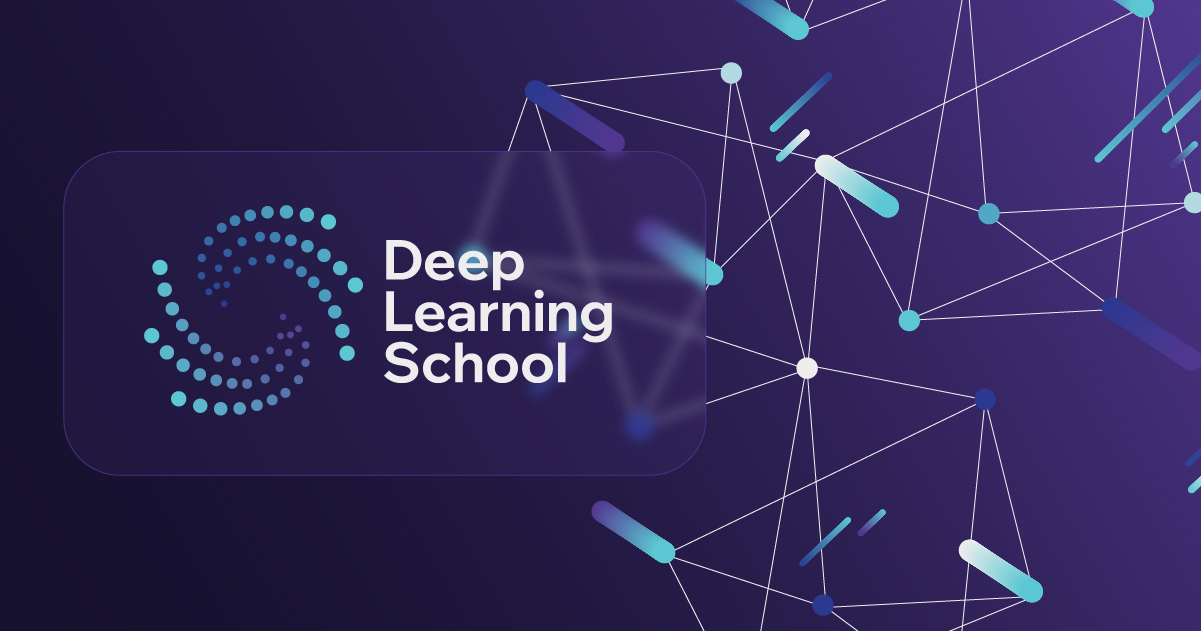


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
# !pip install kagglehub

In [9]:
import os

import imageio
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets
from torchvision import transforms
import torch.nn.functional as F



%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [2]:
from pathlib import Path

In [3]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\jessicali9530\lfw-dataset\versions\4


In [4]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Path to dataset files: C:\Users\k142\.cache\kagglehub\datasets\averkij\lfw-attributes\versions\1


In [5]:
Path(images_path)

WindowsPath('C:/Users/k142/.cache/kagglehub/datasets/jessicali9530/lfw-dataset/versions/4')

In [6]:
# DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
# ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = Path(images_path)
ATTRIBUTES_PATH = Path(attrs_path).joinpath("lfw_attributes.txt")

In [7]:
df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

> Чтение атрибутов для расшифровки

In [8]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):
    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1, )
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns=df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id, 'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids.info())
    df = pd.merge(df_attrs, photo_ids, on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    # Обрезка
    # dy - количество пикселей, обрезаемых сверху и снизу
    # dx - количество пикселей, обрезаемых слева и справа
    #
    # Изменение размера
    # dimx - ширина
    # dimy - высота

    images = df['photo_path'].apply(imageio.imread) \
        .apply(lambda img: img[dy:-dy, dx:-dx]) \
        .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])))

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path", "person", "imagenum"], axis=1)

    return images, attrs

In [9]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset(dimx=44, dimy=44)

### Посмотрим несколько картинок и соединим с атрибутами (имя)

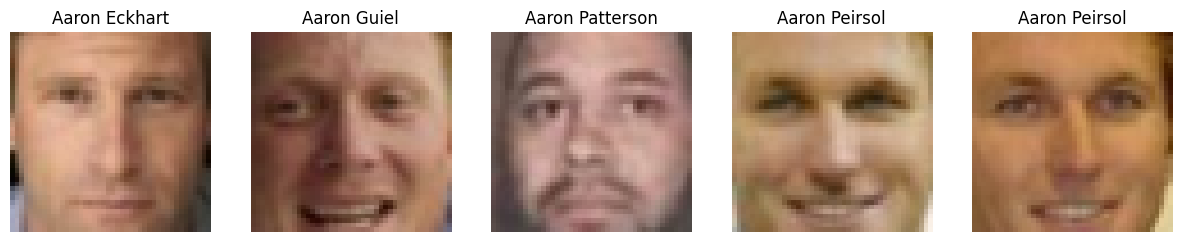

In [10]:
plt.figure(figsize=(15, 3))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])

# plt.tight_layout()
plt.show()

In [11]:
len(images), attrs.shape[0]

(13143, 13143)


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms

class AutoencoderDataset(Dataset):
    def __init__(self, images, indices, transform=None):
        """
        Args:
            images: numpy array в формате (N, H, W, C)
            indices: индексы для выборки
            transform: преобразования (включая ToTensor())
        """
        self.indices = indices
        self.images = images[indices]  # Выбираем данные по индексам (остаётся H x W x C)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]  # Получаем изображение в формате H x W x C

        if self.transform:
            image = self.transform(image)  # Применяем преобразования (включая ToTensor())
        else:
            # Если transform=None, делаем минимальное преобразование в тензор
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0  # HWC -> CHW и [0,255] -> [0,1]

        return image, image  # Для автоэнкодера input и target одинаковы

def get_dataloaders(images, batch_size=32, train_ratio=0.8, val_ratio=0.1):
    """
    Создает DataLoader'ы для train, validation и test

    Args:
        images: numpy array в формате (N, H, W, C)
        batch_size: размер батча
        train_ratio: доля тренировочных данных
        val_ratio: доля валидационных данных
    Returns:
        train_loader, val_loader, test_loader
    """
    # Проверка формата
    if images.ndim != 4 or images.shape[3] not in {1, 3}:
        raise ValueError("Ожидается формат (N, H, W, C), где C=1 или 3")

    # Разделение данных
    n_total = len(images)
    ix = np.random.choice(n_total, n_total, False)  # Перемешанные индексы
    train_size = int(train_ratio * n_total)
    val_size = int(val_ratio * n_total)
    tr, val, ts = np.split(ix, [train_size, train_size + val_size])

    # Стандартные преобразования (HWC -> CHW + нормализация)
    transform = transforms.Compose([
        transforms.ToTensor()  # Конвертирует numpy (H x W x C) в torch (C x H x W) и нормализует [0,1]
    ])

    # Создаем датасеты
    train_dataset = AutoencoderDataset(images, tr, transform=transform)
    val_dataset = AutoencoderDataset(images, val, transform=transform)
    test_dataset = AutoencoderDataset(images, ts, transform=transform)

    # Создаем DataLoader'ы
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [13]:
train_loader, val_loader, test_loader = get_dataloaders(images, batch_size=64)

### Выведем несколько картинок из датасета

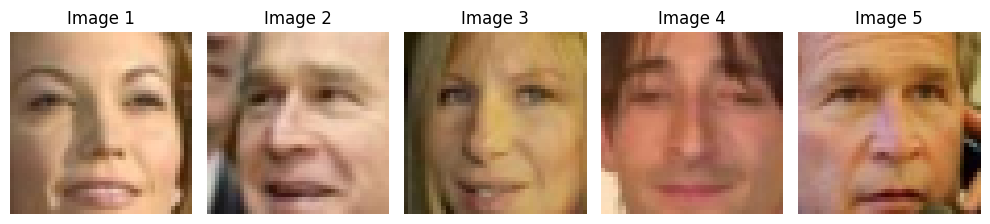

In [14]:
batch_images, _ = next(iter(train_loader))  # Автоэнкодер возвращает (input, target) — берем только input

# Создаем фигуру с 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

# Перебираем первые 5 картинок из батча
for i in range(5):
    single_image = batch_images[i]  # Формат: (C, H, W)

    # Если изображение нормализовано в [0, 1], преобразуем в [0, 255]
    if single_image.max() <= 1.0:
        single_image = single_image * 255.0

    # Преобразуем тензор в numpy и меняем порядок осей для matplotlib (C, H, W) -> (H, W, C)
    image_np = single_image.numpy().transpose(1, 2, 0).astype(np.uint8)

    # Отображаем изображение
    axes[i].imshow(image_np)
    axes[i].axis('off')  # Отключаем оси
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



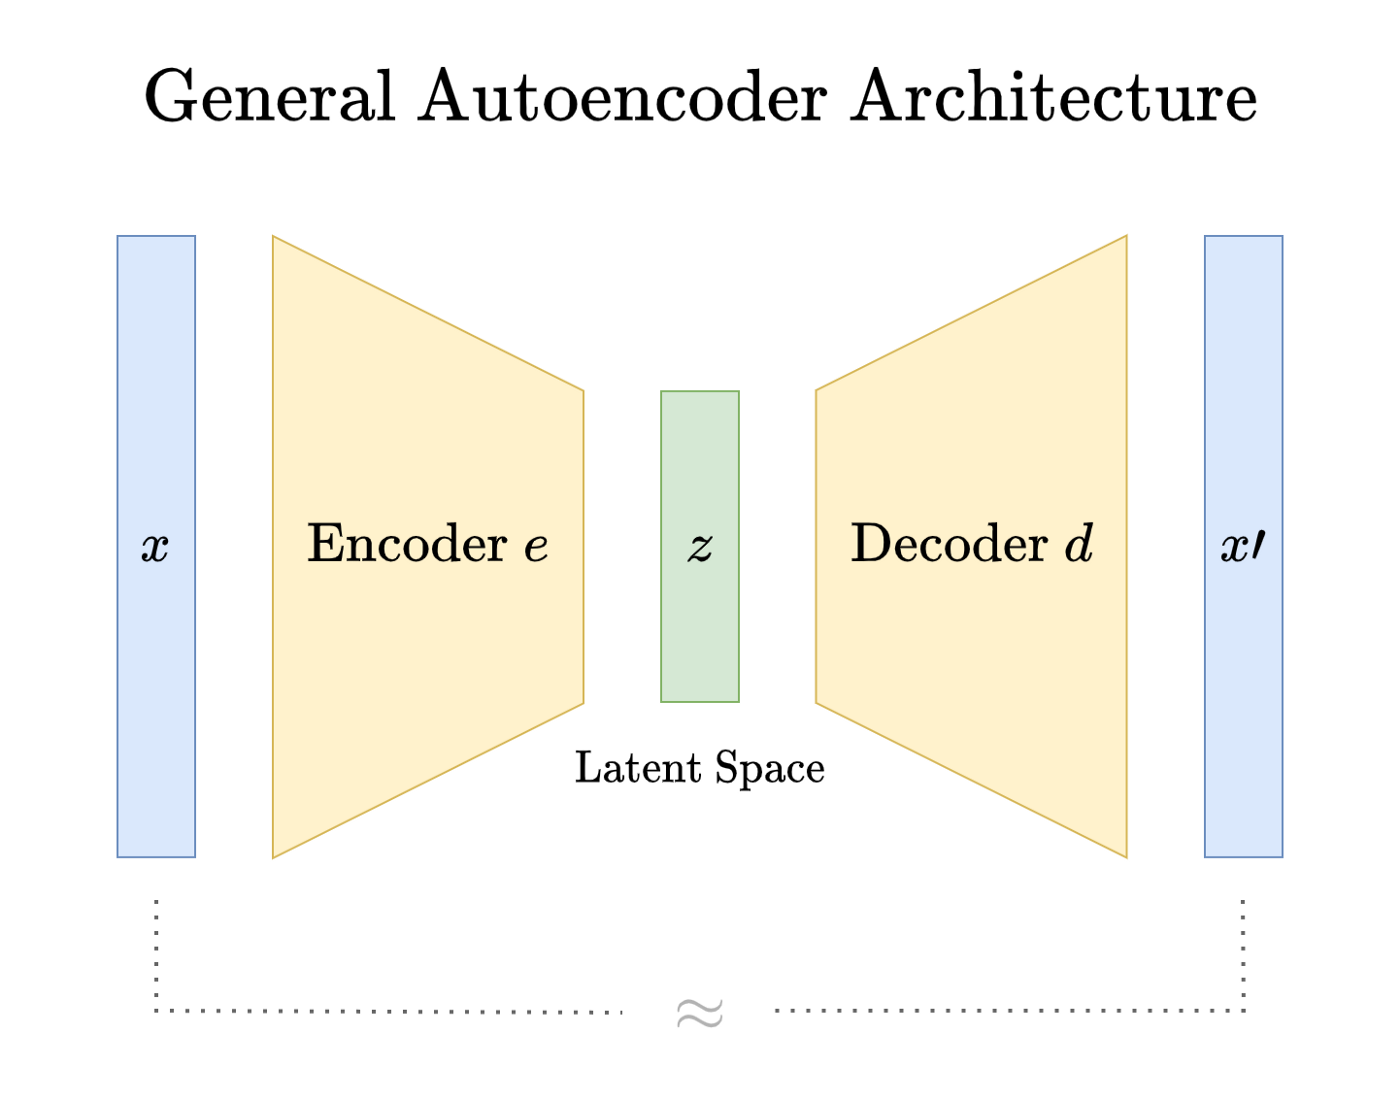

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [18]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(6*6*64, 128)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(128, 6*6*64),
            nn.ReLU(),
            nn.Unflatten(1, (64, 6, 6)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=2),
            nn.AdaptiveAvgPool2d((44, 44)),  # Принудительно устанавливаем нужный размер
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_code = self.encoder(x)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code

> Немного напутал с размерностью, поэтому пришлось поставить принудительно установить выходной размер 44x44 с помощью ***AdaptiveAvgPool2d((44, 44))***. Оставил так, чтобы проверить эту возможность.

In [19]:
model0=Autoencoder()
print(model0)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=2304, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=2304, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 6, 6))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(2, 2))
    (8): AdaptiveAvgPool2d(output_size=(44, 44))
    (9): Sigmoid()
  )
)


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
# Функция для обучения модели
def train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        for batch_idx, (images, _) in enumerate(train_loader):
            images = images.to(device)
            optimizer.zero_grad()
            
            reconstructions, latent = model(images)
            
            loss = criterion(reconstructions, images)
            loss.backward()
            
            optimizer.step()
            epoch_loss += loss.item()
            
            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], '
                      f'Batch [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')
    
    return train_losses

In [ ]:
num_epochs = 50
train_losses = train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device)

### 1 Этап обучения

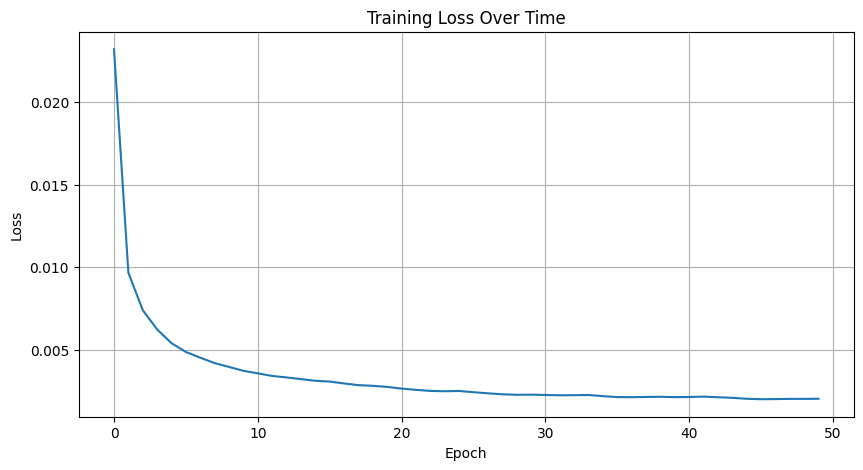

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [60]:
# torch.save(model, 'autoencoder_v1.pth')

In [23]:
# model = torch.load('autoencoder_v1.pth')

> Для обучения достаточно около 20 эпох

In [ ]:
def visualize_reconstruction(model, test_loader, device, num_images=5):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(test_loader))
        images = images[:num_images].to(device)
        
        reconstructions, _ = model(images)
        
        images = images.cpu().numpy()
        reconstructions = reconstructions.cpu().numpy()
        
        plt.figure(figsize=(12, 4))
        for i in range(num_images):
            # Оригинальное изображение
            plt.subplot(2, num_images, i + 1)
            plt.imshow(np.transpose(images[i], (1, 2, 0)))
            plt.title('Original')
            plt.axis('off')
            
            # Реконструкция
            plt.subplot(2, num_images, i + num_images + 1)
            plt.imshow(np.transpose(reconstructions[i], (1, 2, 0)))
            plt.title('Reconstructed')
            plt.axis('off')
        
        plt.tight_layout()
        plt.show()


Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

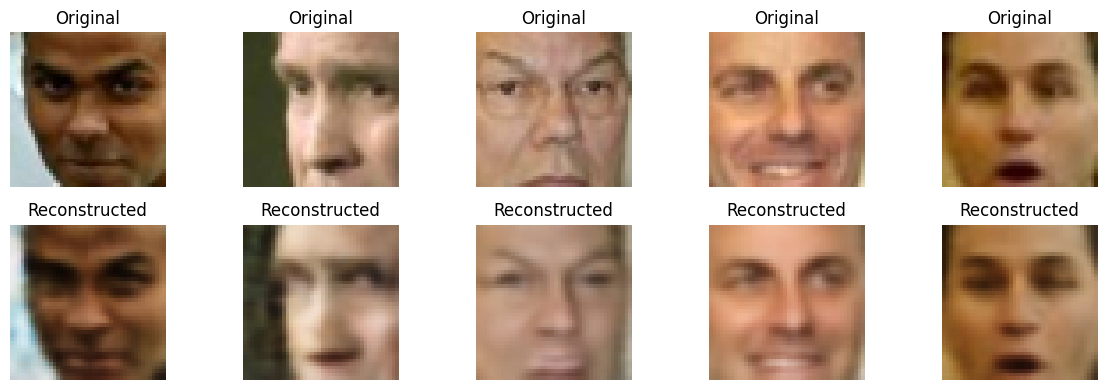

In [ ]:
# Пример использования функции визуализации
visualize_reconstruction(model, test_loader, device)

> Размерность латента - 128. Обучение 50 эпох. Качество реконструкции нормальное.

In [24]:
# Пример использования функции обучения
num_epochs = 20
train_losses = train_autoencoder(model, train_loader, criterion, optimizer, num_epochs, device)

Epoch [1/20], Batch [100/165], Loss: 0.0203
Epoch [1/20], Average Loss: 0.0245
Epoch [2/20], Batch [100/165], Loss: 0.0085
Epoch [2/20], Average Loss: 0.0094
Epoch [3/20], Batch [100/165], Loss: 0.0069
Epoch [3/20], Average Loss: 0.0073
Epoch [4/20], Batch [100/165], Loss: 0.0059
Epoch [4/20], Average Loss: 0.0062
Epoch [5/20], Batch [100/165], Loss: 0.0051
Epoch [5/20], Average Loss: 0.0054
Epoch [6/20], Batch [100/165], Loss: 0.0046
Epoch [6/20], Average Loss: 0.0048
Epoch [7/20], Batch [100/165], Loss: 0.0043
Epoch [7/20], Average Loss: 0.0045
Epoch [8/20], Batch [100/165], Loss: 0.0040
Epoch [8/20], Average Loss: 0.0042
Epoch [9/20], Batch [100/165], Loss: 0.0037
Epoch [9/20], Average Loss: 0.0040
Epoch [10/20], Batch [100/165], Loss: 0.0035
Epoch [10/20], Average Loss: 0.0038
Epoch [11/20], Batch [100/165], Loss: 0.0034
Epoch [11/20], Average Loss: 0.0036
Epoch [12/20], Batch [100/165], Loss: 0.0032
Epoch [12/20], Average Loss: 0.0034
Epoch [13/20], Batch [100/165], Loss: 0.0032
E

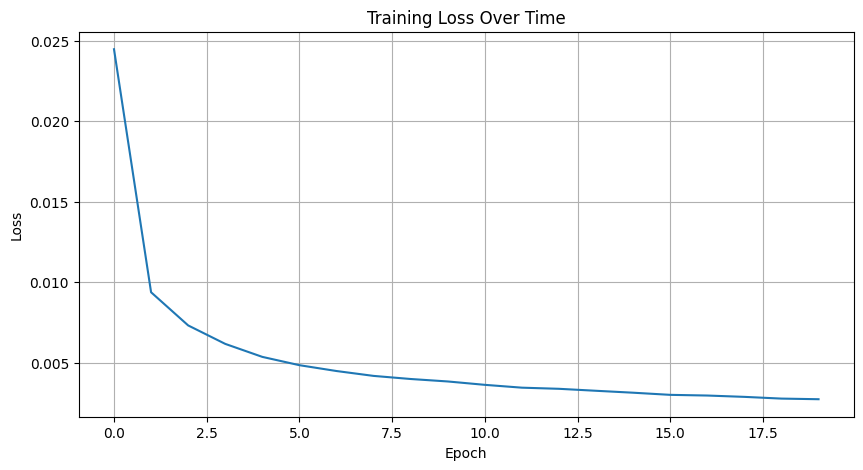

In [25]:

# Визуализация процесса обучения
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

Что вы можете сказать про результат?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [26]:
# Функция для получения статистик латентного пространства
def get_latent_stats(model, dataloader, device, num_samples=1000):
    model.eval()
    latent_vectors = []
    
    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i * images.shape[0] >= num_samples:
                break
            images = images.to(device)
            _, latent = model(images)
            latent_vectors.append(latent.cpu().numpy())
    
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    mean = np.mean(latent_vectors, axis=0)
    std = np.std(latent_vectors, axis=0)
    
    return mean, std

# Функция для генерации новых изображений
def generate_images(model, num_images, latent_mean, latent_std, device):
    model.eval()
    # Генерируем случайные векторы с учетом статистик реальных данных
    z = np.random.normal(latent_mean, latent_std, (num_images, 128))
    
    with torch.no_grad():
        z = torch.FloatTensor(z).to(device)
        generated_images, _ = model.decoder(z), None
    
    return generated_images

# Функция для визуализации сгенерированных изображений
def visualize_generated(images, num_rows=5, num_cols=5):
    plt.figure(figsize=(8, 8))
    for i in range(min(num_rows * num_cols, len(images))):
        plt.subplot(num_rows, num_cols, i + 1)
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


### Визуализация новых изображений

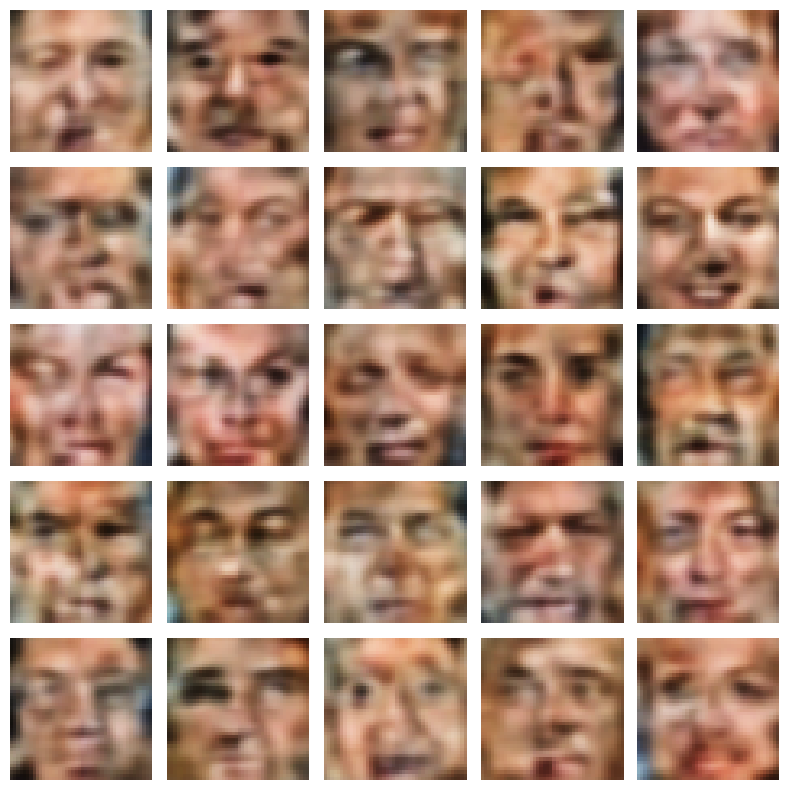

In [27]:

latent_mean, latent_std = get_latent_stats(model, train_loader, device)

num_images = 25  # 5x5 сетка
generated_images = generate_images(model, num_images, latent_mean, latent_std, device)

visualize_generated(generated_images)


> Качество не очень хорошее, но типовые характеристики лиц улавливаются

### Сделаем интерполяцию между двух точек в латентном пространстве

In [28]:
def interpolate_latent(model, z1, z2, num_steps=10, device='cuda'):
    alphas = np.linspace(0, 1, num_steps)
    interpolated_images = []
    
    with torch.no_grad():
        for alpha in alphas:
            z = torch.FloatTensor(z1 * (1 - alpha) + z2 * alpha).to(device)
            image, _ = model.decoder(z.unsqueeze(0)), None
            interpolated_images.append(image[0])
    
    return torch.stack(interpolated_images)

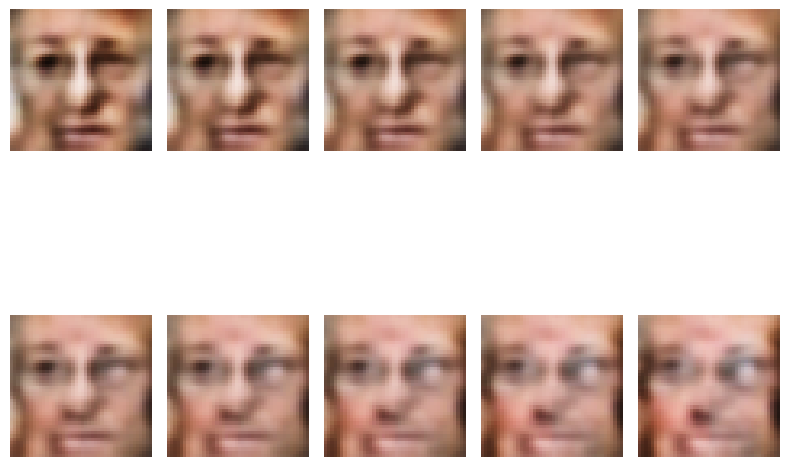

In [29]:
z1 = np.random.normal(latent_mean, latent_std, (128,))
z2 = np.random.normal(latent_mean, latent_std, (128,))

interpolated = interpolate_latent(model, z1, z2, num_steps=10, device=device)

# Визуализируем интерполяцию
visualize_generated(interpolated, num_rows=2, num_cols=5)

> Качество немного замылено, но переход от одной точки к другой явно наблюдается

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [54]:
attrs['Smiling'] = attrs['Smiling'].astype(float)

> преобразуем атрибут в число

In [55]:
attrs.Smiling.describe()

count    13143.000000
mean        -0.150700
std          1.127722
min         -2.686594
25%         -1.065725
50%         -0.320783
75%          0.766401
max          2.839994
Name: Smiling, dtype: float64

In [78]:
attrs.loc[attrs.Smiling > 2, 'Smiling'].count()

342

### Выведем изоражения с улыбками

In [36]:
idx_smiling=attrs.loc[attrs.Smiling > 2 , 'Smiling'][:5].index.to_list()

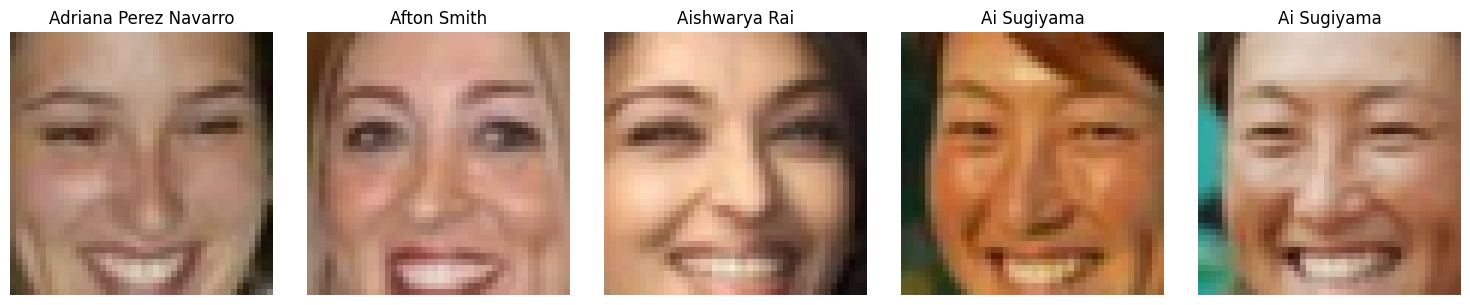

In [37]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

### Выведем изображения грустными лицами

In [34]:
idx_smiling=attrs.loc[attrs.Smiling < -2 , 'Smiling'][:5].index.to_list()

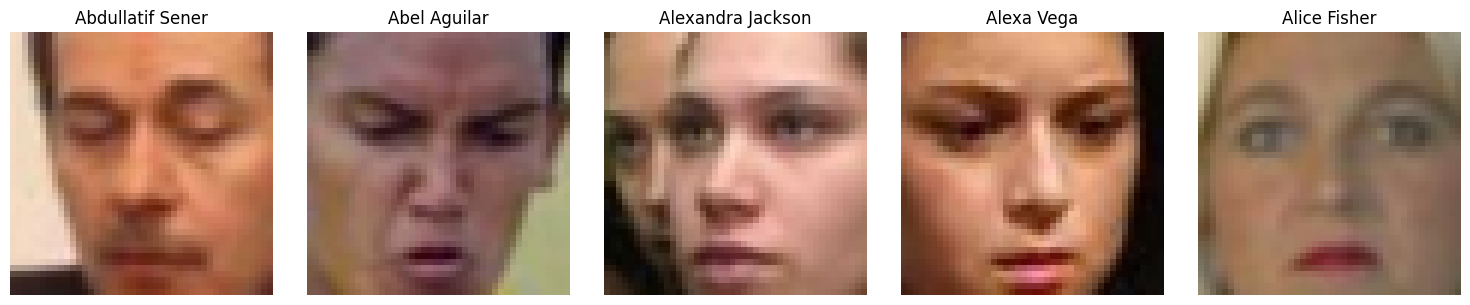

In [35]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

In [52]:
idx_smiling=attrs.loc[attrs.Sunglasses > 1 , 'Sunglasses'][:5].index.to_list()

### Выведем изображения в очках

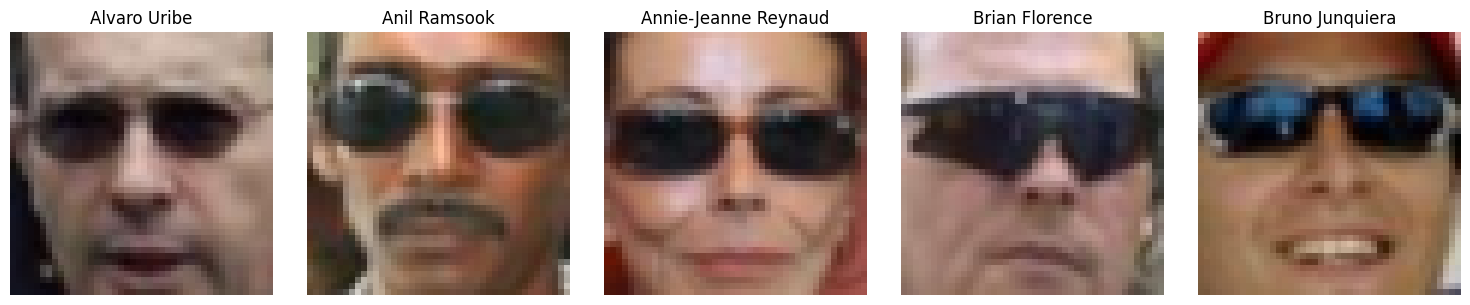

In [53]:
plt.figure(figsize=(15, 3))

ci=0
for i in idx_smiling:
    plt.subplot(1, 5, ci + 1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(df_attrs.iloc[i]['person'])
    ci +=1

plt.tight_layout()
plt.show()

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

In [69]:
def get_smile_vectors(model, images, attrs, attr='Smiling', treshhold=2, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений формата (N, H, W, C)
        attrs: pandas DataFrame с атрибутами
        device: устройство для вычислений
    """

    smiling_indices = attrs.loc[attrs[attr] > treshhold, attr][:15].index.to_list()
    non_smiling_indices = attrs.loc[attrs[attr] < -2, attr][:15].index.to_list()
    
    # Преобразуем изображения в тензоры и меняем порядок размерностей NHWC -> NCHW
    smiling_images = torch.FloatTensor(images[smiling_indices]).permute(0, 3, 1, 2) / 255.0
    non_smiling_images = torch.FloatTensor(images[non_smiling_indices]).permute(0, 3, 1, 2) / 255.0
    
    model = model.to(device)
    smiling_images = smiling_images.to(device)
    non_smiling_images = non_smiling_images.to(device)
    
    # 2. Получаем латентные векторы
    model.eval()
    with torch.no_grad():
        # Для 1 типа
        output_smiling = model(smiling_images)
        if isinstance(output_smiling, tuple):
            _, smiling_latent = output_smiling
        else:
            smiling_latent = output_smiling
            
        # Для 2 типа
        output_non_smiling = model(non_smiling_images)
        if isinstance(output_non_smiling, tuple):
            _, non_smiling_latent = output_non_smiling
        else:
            non_smiling_latent = output_non_smiling
    
    # 3. Вычисляем средние векторы и их разность
    mean_smiling = torch.mean(smiling_latent, dim=0)
    mean_non_smiling = torch.mean(non_smiling_latent, dim=0)
    smile_vector = mean_smiling - mean_non_smiling
    
    return smile_vector, smiling_indices, non_smiling_indices

def add_smile(model, image, smile_vector, alpha=1.0, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Добавляет атрибут изображению
    
    Args:
        model: обученная модель автоэнкодера
        image: исходное изображение (numpy array формата H x W x C)
        smile_vector: вектор улыбки
        alpha: коэффициент интенсивности улыбки
        device: устройство для вычислений
    """
    image_tensor = torch.FloatTensor(image).unsqueeze(0).permute(0, 3, 1, 2) / 255.0
    image_tensor = image_tensor.to(device)
    model = model.to(device)
    smile_vector = smile_vector.to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        if isinstance(output, tuple):
            _, latent = output
        else:
            latent = output
            
        new_latent = latent + alpha * smile_vector
        generated_image = model.decoder(new_latent)
    
    result = generated_image.cpu().squeeze(0).permute(1, 2, 0).numpy()
    result = np.clip(result * 255, 0, 255).astype(np.uint8)
    
    return result

def visualize_smile_transformation(model, images, attrs, attr='Smiling', treshhold=2, n_samples=5):
    """
    Визуализирует процесс добавления улыбки к изображениям
    
    Args:
        model: обученная модель автоэнкодера
        images: numpy array изображений
        attrs: pandas DataFrame с атрибутами
        n_samples: количество примеров для визуализации
    """
    import matplotlib.pyplot as plt
    
    # Получаем вектор улыбки
    smile_vector, _, _ = get_smile_vectors(model, images, attrs, attr, treshhold)
    
    # Выбираем 1 тип
    non_smiling_indices = attrs.loc[attrs[attr] < -2,  attr][:n_samples].index.to_list()
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    for i, idx in enumerate(non_smiling_indices):
        # Исходное изображение
        axes[i, 0].imshow(images[idx])
        axes[i, 0].set_title('Оригинал')
        axes[i, 0].axis('off')
        
        # Альфа 0.5
        with_smile_05 = add_smile(model, images[idx], smile_vector, alpha=0.5)
        axes[i, 1].imshow(with_smile_05)
        axes[i, 1].set_title('Улыбка (α=0.5)')
        axes[i, 1].axis('off')
        
        # Альфа 1.0
        with_smile_10 = add_smile(model, images[idx], smile_vector, alpha=1.0)
        axes[i, 2].imshow(with_smile_10)
        axes[i, 2].set_title('Улыбка (α=1.0)')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show() 

In [70]:
get_smile_vectors(model, images, attrs, attr='Smiling', treshhold=2)

(tensor([-0.0138,  0.5528,  0.4414, -0.4814, -0.5479,  0.2789,  1.4614,  0.1529,
          1.1174,  1.7284, -0.5132, -0.3974,  1.6948, -1.3433,  1.5766,  0.1819,
         -1.0668, -0.2470,  0.4693,  1.1304, -1.7321, -0.1119, -0.1823, -1.2855,
          0.8052,  0.9756, -0.0181,  0.8279, -0.7698, -0.7028, -1.6297, -0.5980,
         -0.6379, -0.3280, -0.6316, -1.0263,  0.1830,  0.0831,  0.3334,  0.3939,
         -1.4028, -1.2085, -1.1107, -1.4644,  1.8751, -0.3241, -1.0025, -1.3799,
         -0.4930, -0.0743, -0.3587,  0.3759, -0.3553,  0.4018,  1.1800,  0.2091,
         -0.7224,  0.7943,  0.7712, -0.5273, -0.5040,  1.0200, -0.5455,  0.2054,
         -0.1882, -0.7528, -0.5678, -0.4842, -0.7234, -0.1275, -0.7459,  0.1347,
         -0.2876, -0.1370, -1.5737, -0.4301,  0.0757, -1.1922,  0.5825, -0.7156,
          0.0462, -0.8594, -0.0861, -0.5967, -0.7838,  0.5367,  0.5355,  0.2413,
          0.8549, -0.2797, -0.3739, -0.9874, -0.5867,  1.2443, -0.9493,  1.2673,
         -0.9105, -0.5915, -

### Пририсуем улыбки

Количество улыбающихся людей: 15
Количество не улыбающихся людей: 15
Размерность вектора улыбки: torch.Size([128])


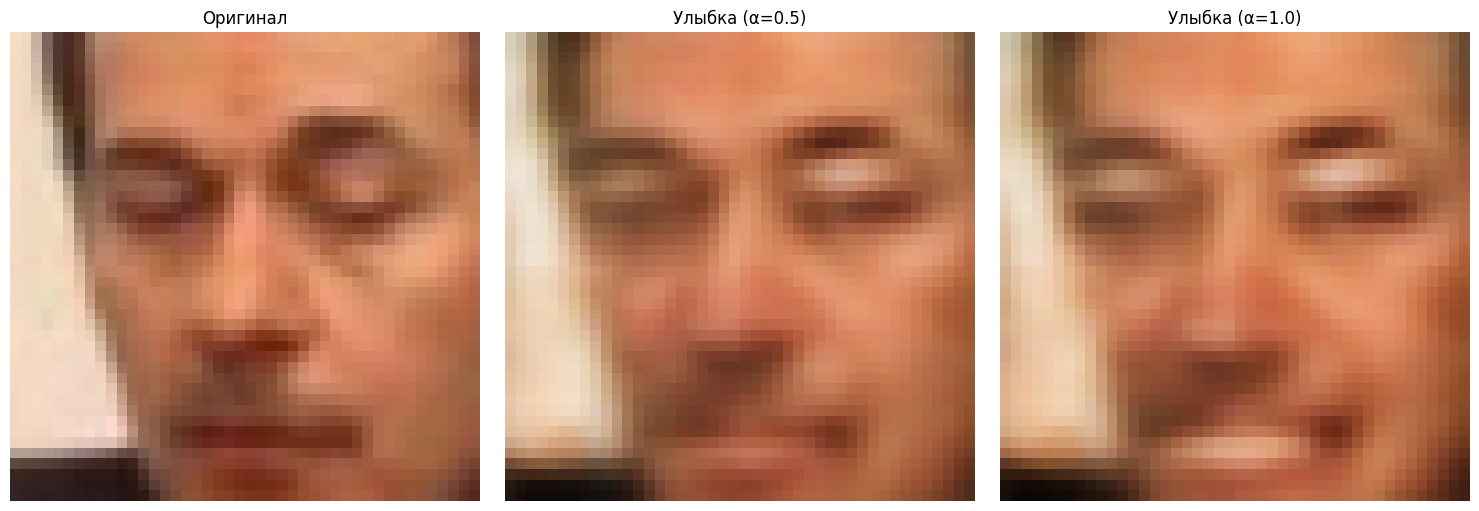


Визуализация трансформации для 5 изображений:


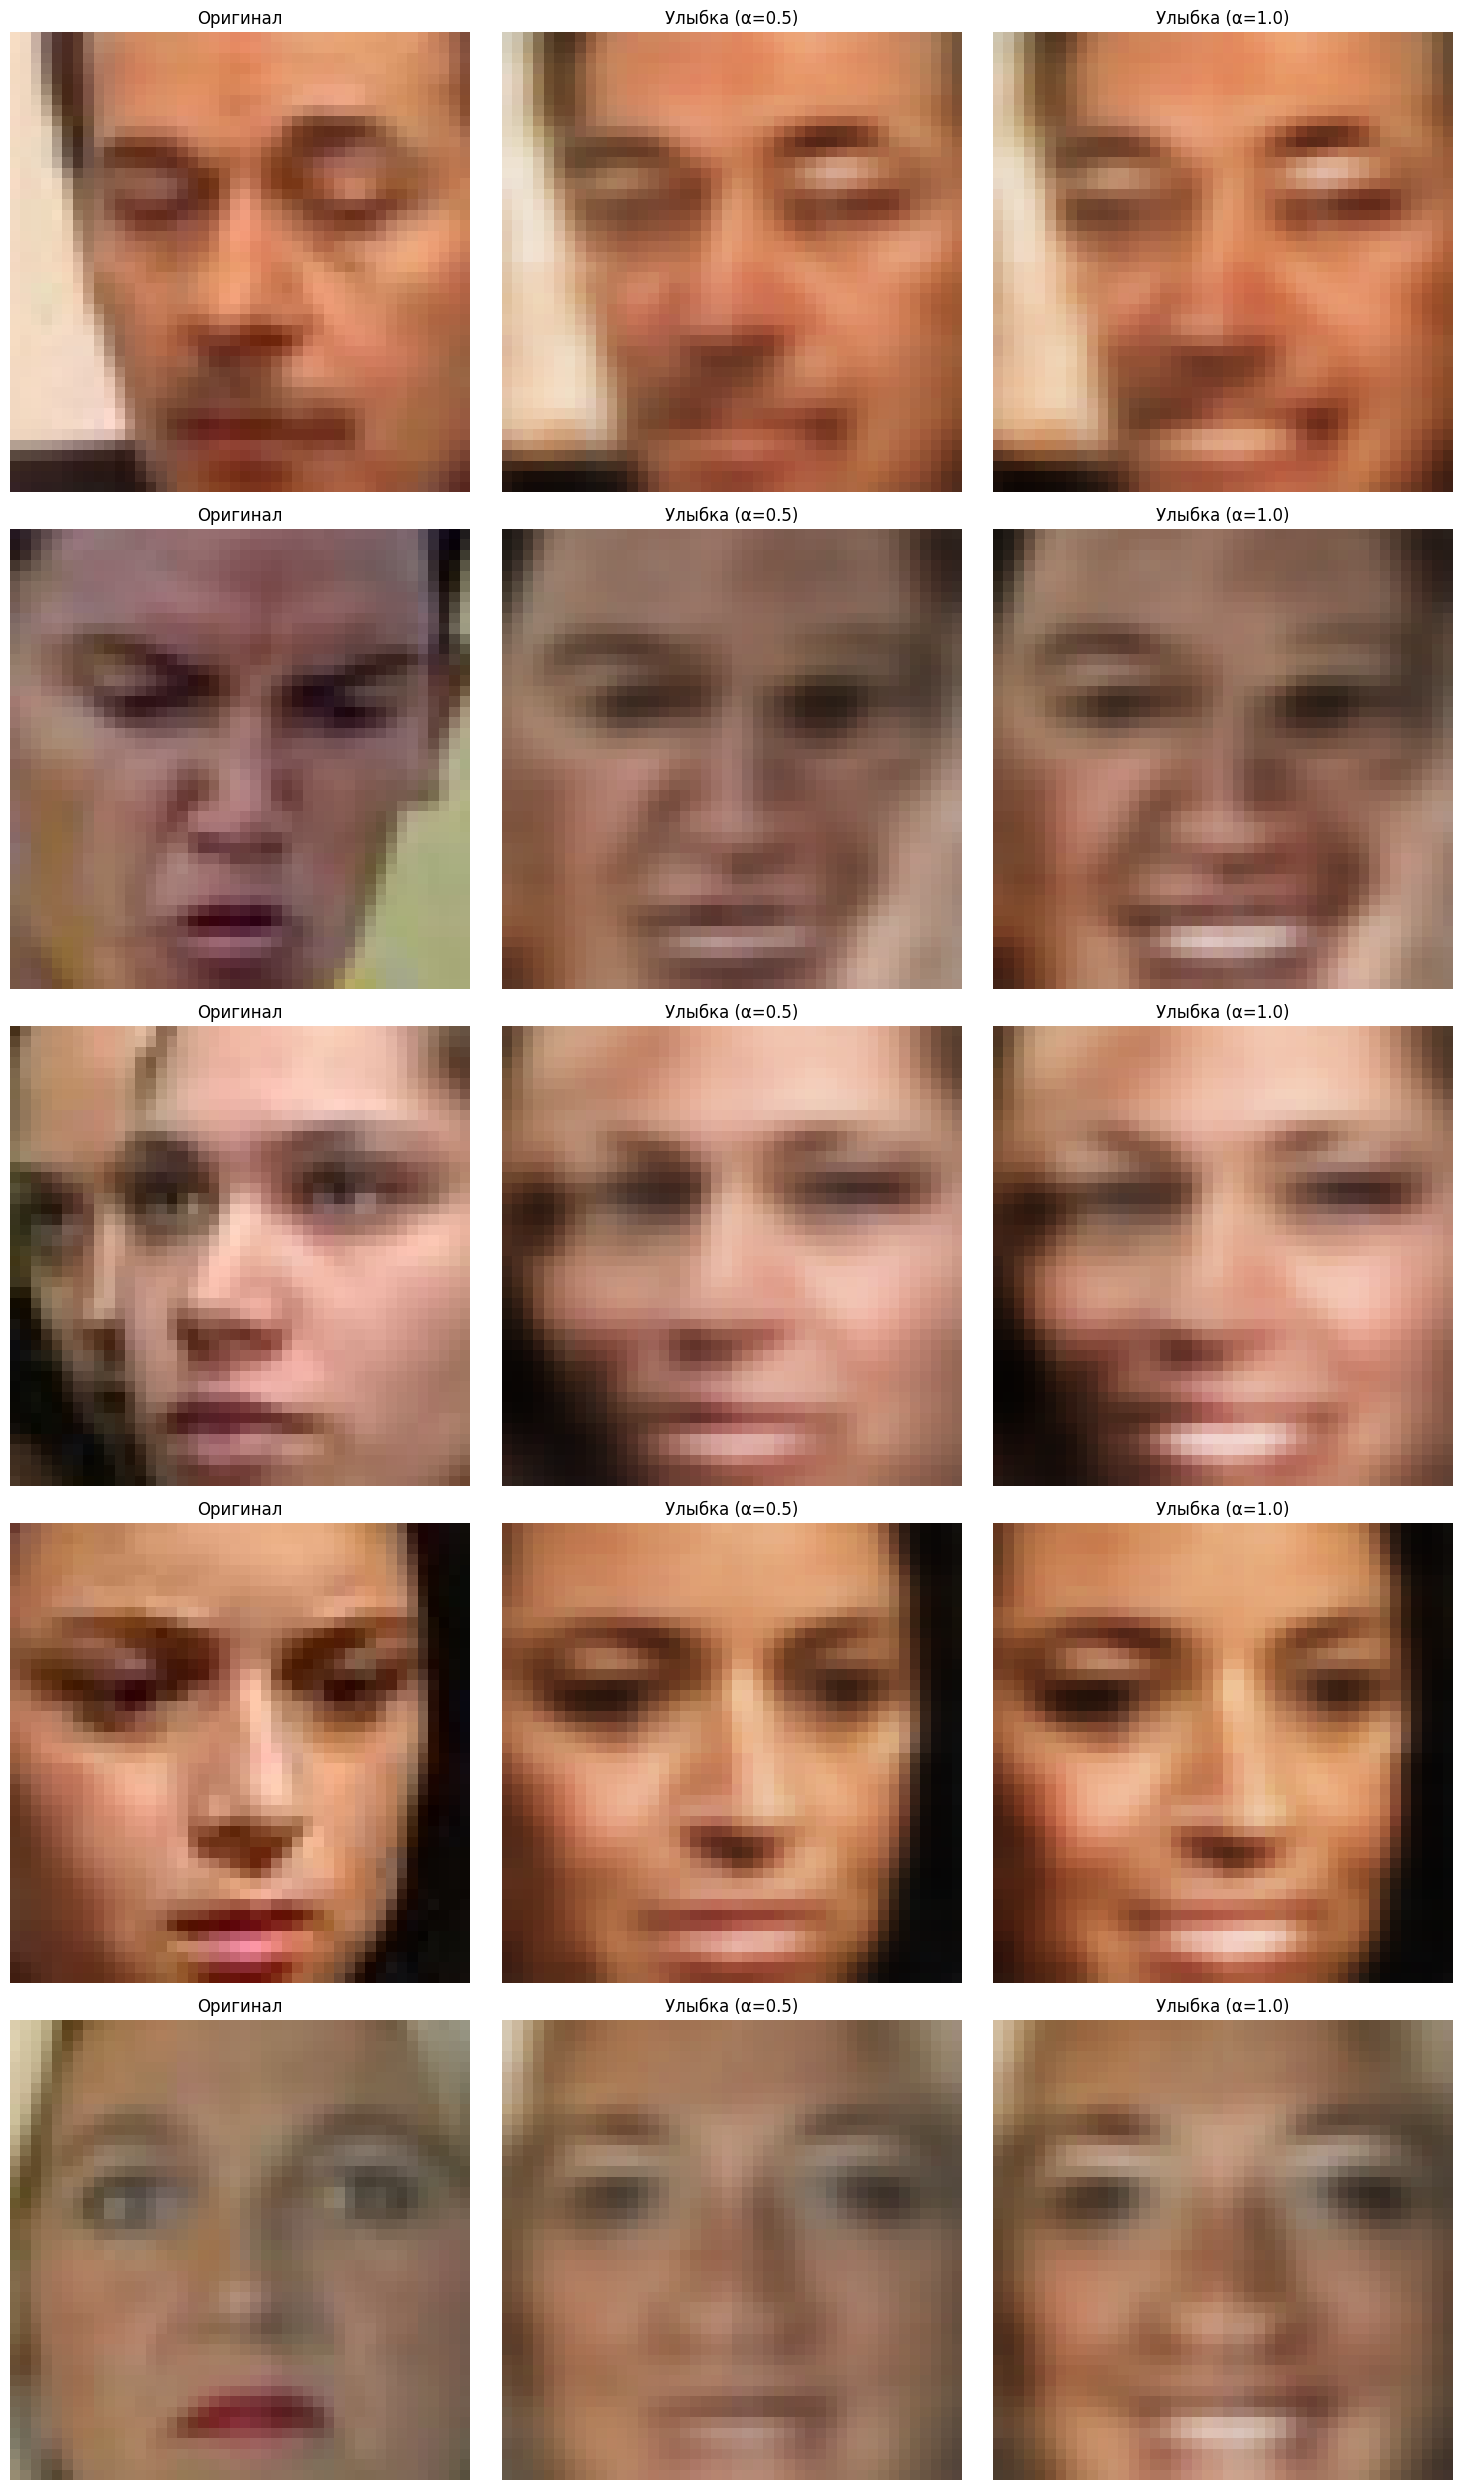

In [71]:
# Получение вектора улыбки
try:
    smile_vector, smiling_indices, non_smiling_indices = get_smile_vectors(model, images, attrs)
    print(f"Количество улыбающихся людей: {len(smiling_indices)}")
    print(f"Количество не улыбающихся людей: {len(non_smiling_indices)}")
    print(f"Размерность вектора улыбки: {smile_vector.shape}")
except Exception as e:
    print(f"Ошибка при получении вектора улыбки: {e}")

# Пример добавления улыбки к одному изображению
try:
    test_idx = non_smiling_indices[0]
    
    # Создаем сетку для визуализации
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Исходное изображение
    axes[0].imshow(images[test_idx])
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    # Добавляем улыбку с разной интенсивностью
    for i, alpha in enumerate([0.5, 1.0]):
        result = add_smile(model, images[test_idx], smile_vector, alpha=alpha)
        axes[i+1].imshow(result)
        axes[i+1].set_title(f'Улыбка (α={alpha})')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при добавлении улыбки к одному изображению: {e}")

# Визуализация нескольких примеров
try:
    print("\nВизуализация трансформации для 5 изображений:")
    visualize_smile_transformation(model, images, attrs, n_samples=5)
except Exception as e:
    print(f"Ошибка при визуализации нескольких примеров: {e}")

> Сделать улыбки для грусных лиц это очень сложно, но модель справилась! Преемственность средняя, но модель очень сильно пыталась

### Пририсуем очки

Количество улыбающихся людей: 15
Количество не улыбающихся людей: 15
Размерность вектора улыбки: torch.Size([128])


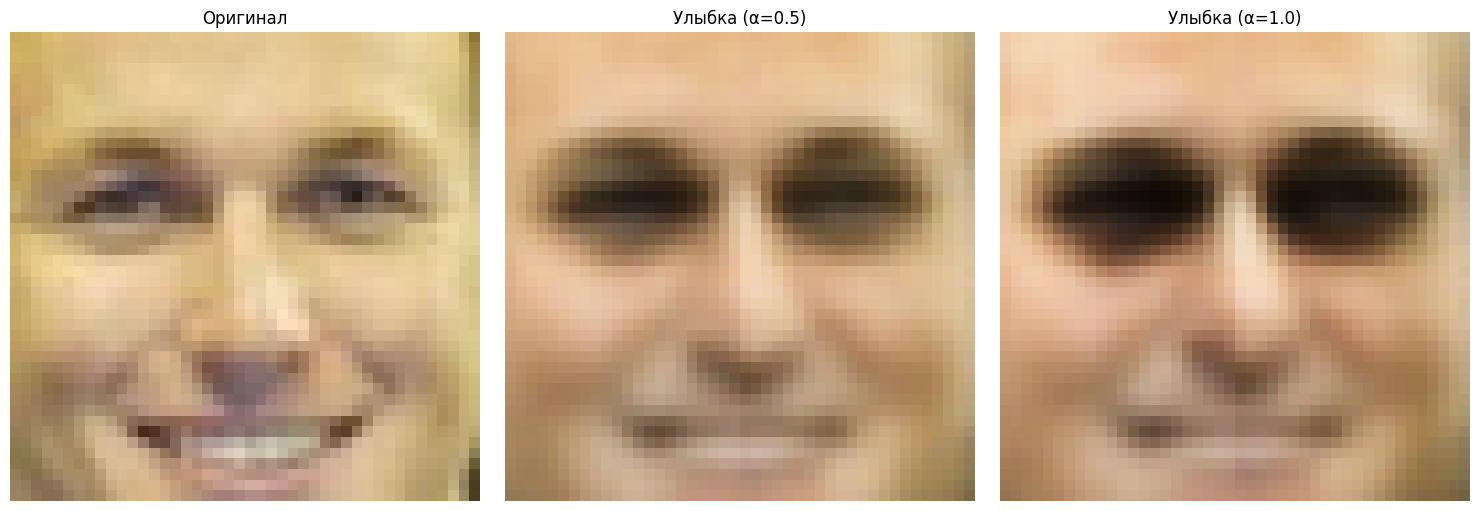


Визуализация трансформации для 5 изображений:


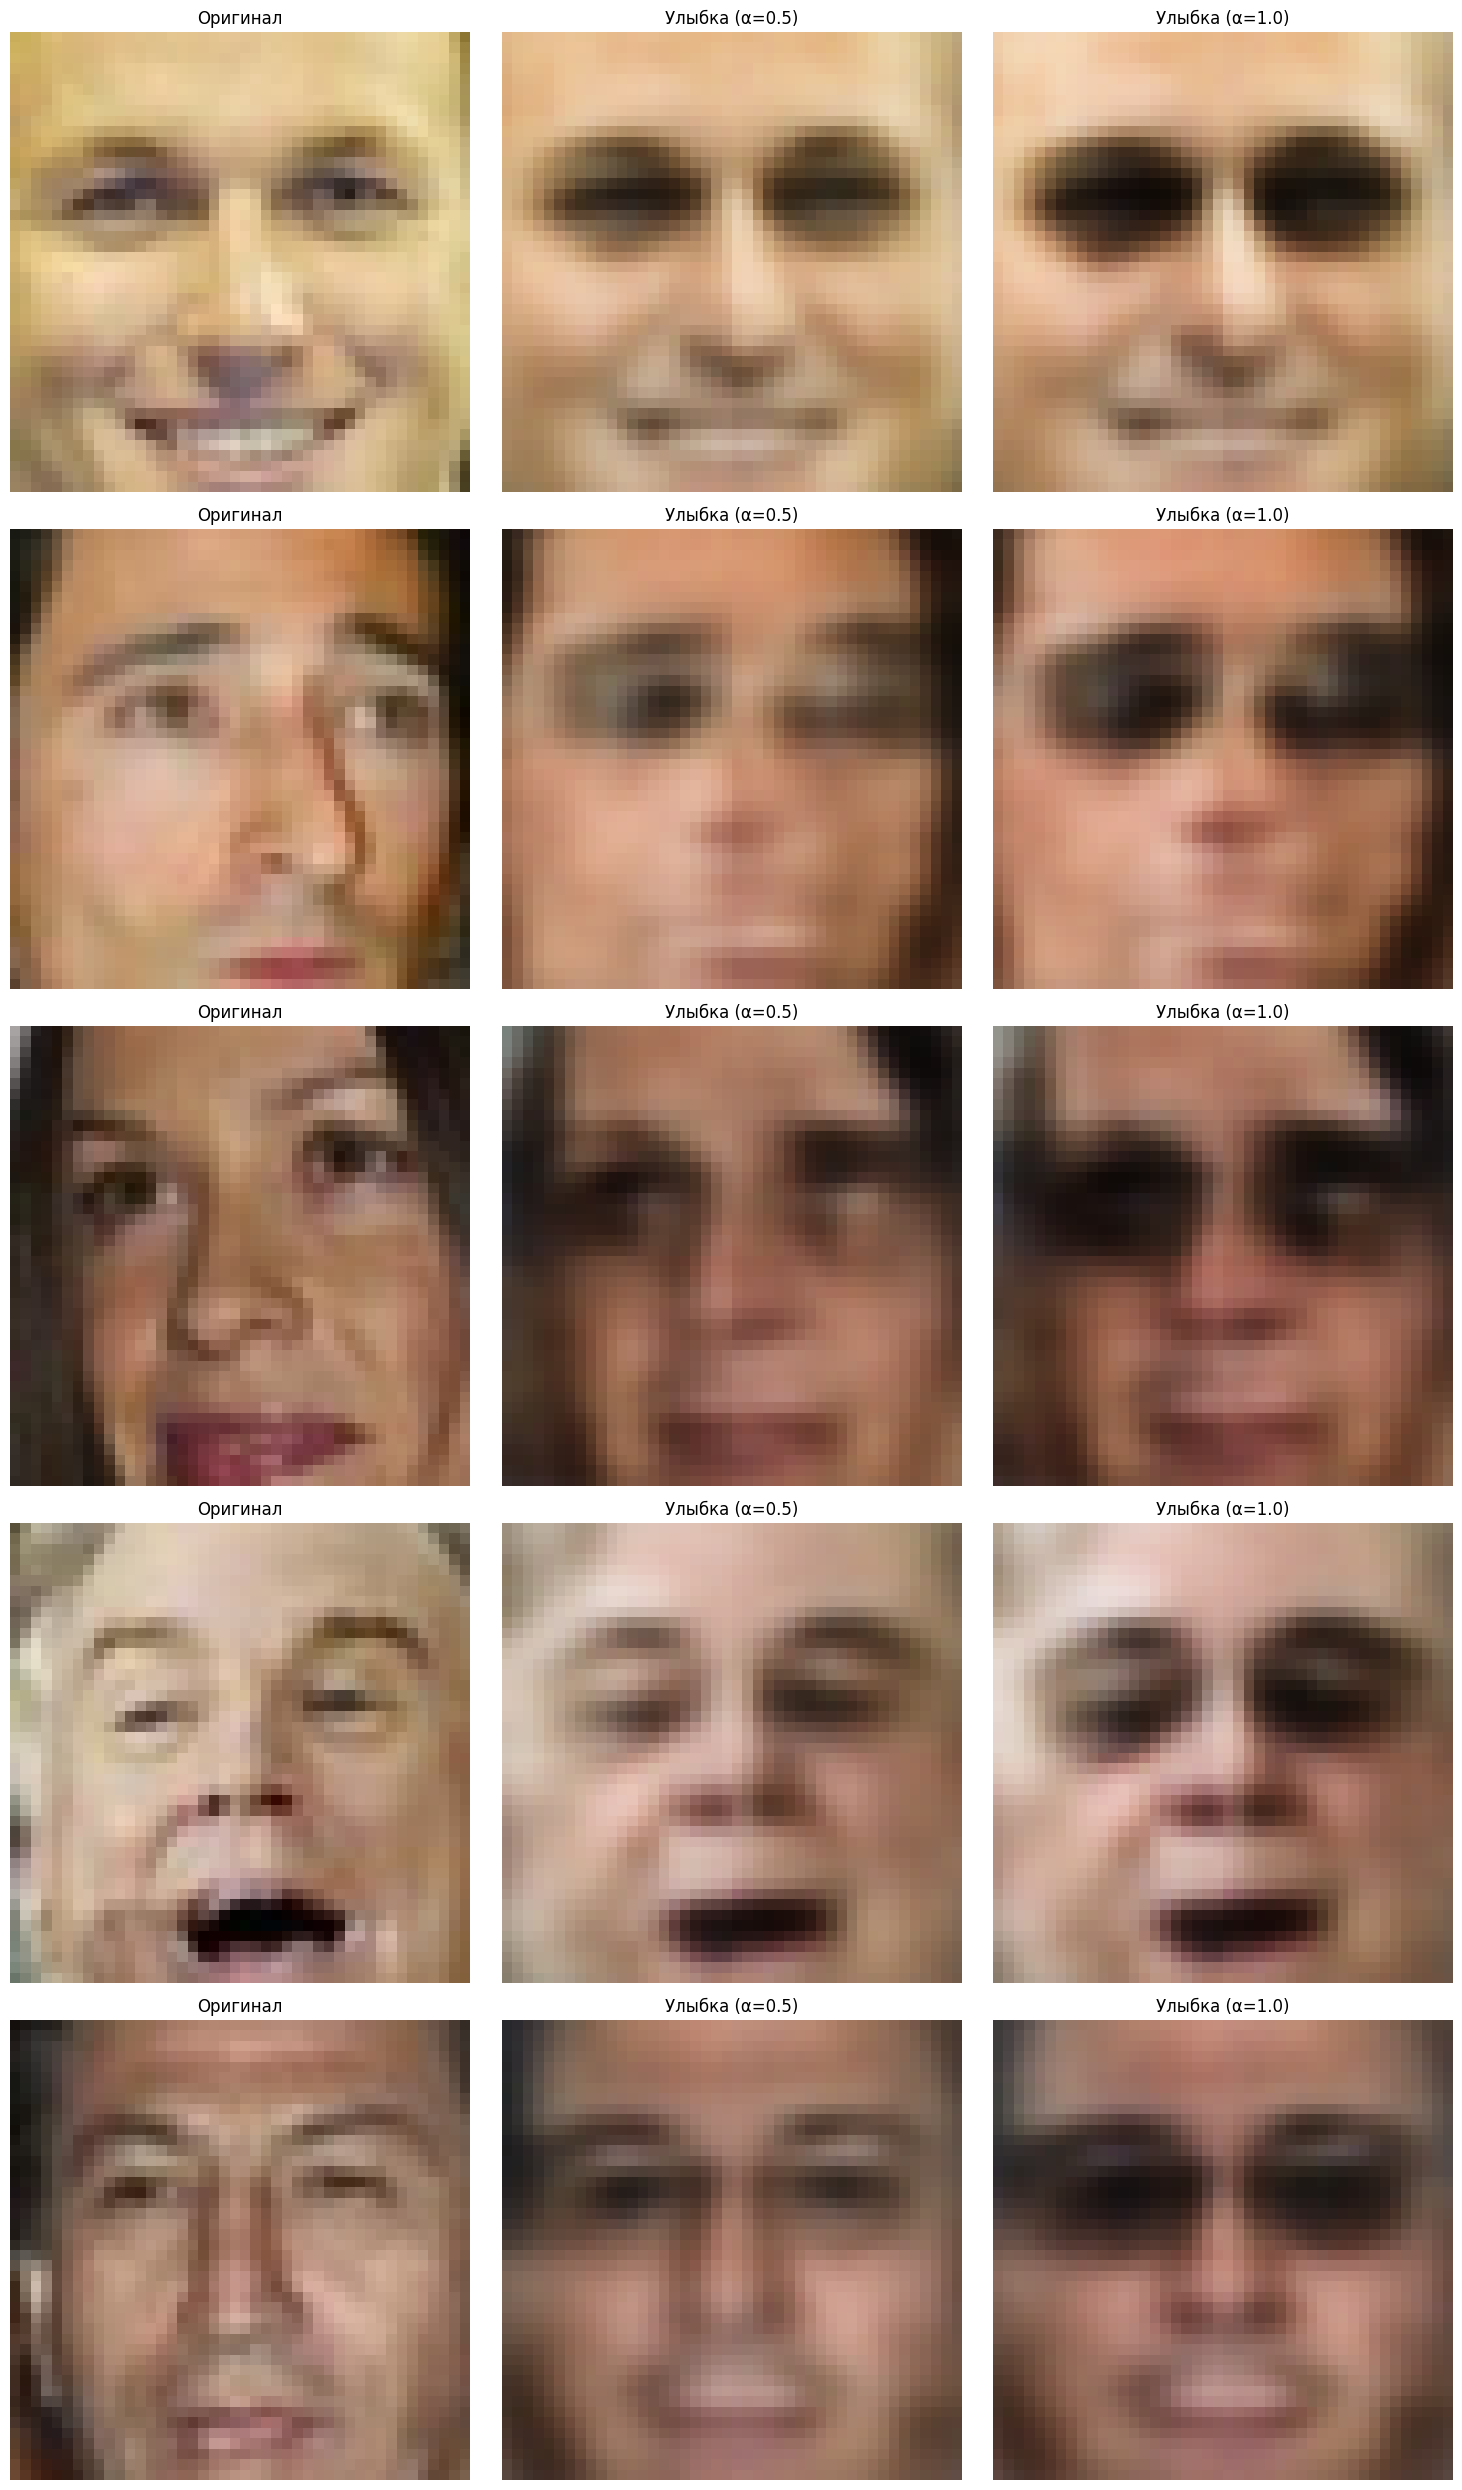

In [73]:
try:
    smile_vector, smiling_indices, non_smiling_indices = get_smile_vectors(model, images, attrs, attr='Sunglasses', treshhold=1)
    print(f"Количество улыбающихся людей: {len(smiling_indices)}")
    print(f"Количество не улыбающихся людей: {len(non_smiling_indices)}")
    print(f"Размерность вектора улыбки: {smile_vector.shape}")
except Exception as e:
    print(f"Ошибка при получении вектора улыбки: {e}")

try:
    test_idx = non_smiling_indices[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(images[test_idx])
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    for i, alpha in enumerate([0.5, 1.0]):
        result = add_smile(model, images[test_idx], smile_vector, alpha=alpha)
        axes[i+1].imshow(result)
        axes[i+1].set_title(f'Улыбка (α={alpha})')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при добавлении улыбки к одному изображению: {e}")

# Визуализация нескольких примеров
try:
    print("\nВизуализация трансформации для 5 изображений:")
    visualize_smile_transformation(model, images, attrs,  attr='Sunglasses', treshhold=1, n_samples=5)
except Exception as e:
    print(f"Ошибка при визуализации нескольких примеров: {e}")

> Очки пририсованны, но окончательные лица имеют только относительную схожесть на оригинал